# 02_Core_Concepts.ipynb

---

# Working Intuition

Elastic Net combines the behavior of **Ridge Regression** and **Lasso Regression** into a single model.

Recall:

* **Ridge** tries to make coefficients **small**, but almost never exactly zero.
* **Lasso** tries to make some coefficients **exactly zero**, effectively removing features.

Elastic Net asks:

> "Can we reduce coefficient sizes like Ridge **and** remove unnecessary features like Lasso?"

The answer is **yes**, by applying **both penalties simultaneously**.

---

## Intuition Step-by-Step

Suppose our Linear Regression model is

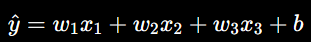

Without regularization, training tries only to minimize prediction error.

Example:

| Feature  | Coefficient |
| -------- | ----------: |
| Area     |          45 |
| Bedrooms |          30 |
| Garage   |          18 |
| ZipCode  |          15 |

Some coefficients may become unnecessarily large.

---

### Ridge's View

Ridge says:

> Large coefficients are risky.

So it shrinks them.

Example:

| Feature  | Before | After Ridge |
| -------- | -----: | ----------: |
| Area     |     45 |          30 |
| Bedrooms |     30 |          20 |
| Garage   |     18 |          10 |
| ZipCode  |     15 |           8 |

Notice:

No coefficient becomes zero.

---

### Lasso's View

Lasso says:

> If a feature isn't useful, remove it completely.

Example

| Feature  | Before | After Lasso |
| -------- | -----: | ----------: |
| Area     |     45 |          39 |
| Bedrooms |     30 |          24 |
| Garage   |     18 |           0 |
| ZipCode  |     15 |           0 |

Now only important features remain.

---

### Elastic Net's View

Elastic Net combines both ideas.

Example

| Feature  | Before | After Elastic Net |
| -------- | -----: | ----------------: |
| Area     |     45 |                32 |
| Bedrooms |     30 |                22 |
| Garage   |     18 |                 7 |
| ZipCode  |     15 |                 0 |

Notice:

* Coefficients become smaller.
* Some coefficients become exactly zero.
* Important correlated features are usually kept together.

---

## Why is this useful?

Imagine two features:

```text
Height
Weight
```

Both contain useful information.

### Ridge

Keeps both.

```text
Height → 0.8
Weight → 1.1
```

---

### Lasso

May keep only one.

```text
Height → 1.5
Weight → 0
```

---

### Elastic Net

Often keeps both but shrinks them.

```text
Height → 0.6
Weight → 0.9
```

This often produces a more stable model.

---

# Important Terminology

---

## 1. Coefficient

The weight assigned to a feature.

Example

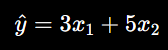

3 and 5 are coefficients.

---

## 2. Regularization

Adding a penalty to discourage overly large coefficients.

Purpose:

* Reduce overfitting
* Improve generalization

---

## 3. L1 Penalty

Also called:

**Manhattan Norm**

Formula

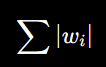

Effect:

* Can make coefficients exactly zero.
* Performs feature selection.

---

## 4. L2 Penalty

Also called:

**Euclidean Norm**

Formula

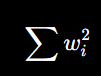

Effect:

* Shrinks coefficients.
* Rarely makes them zero.

---

## 5. Alpha (α)

Controls the **overall strength of regularization**.

Small alpha

```text
Behaves closer to Linear Regression
```

Large alpha

```text
Stronger regularization
```

Higher alpha means:

* Smaller coefficients
* Simpler model
* Higher bias
* Lower variance

---

## 6. l1_ratio

The most important parameter unique to Elastic Net.

It controls **how much L1 vs L2 penalty** is used.

Range

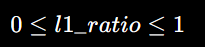

---

### Case 1

```python
l1_ratio = 0
```

Only L2 penalty.

Equivalent to Ridge Regression.

---

### Case 2

```python
l1_ratio = 1
```

Only L1 penalty.

Equivalent to Lasso Regression.

---

### Case 3

```python
l1_ratio = 0.5
```

Equal mix.

Uses both penalties equally.

---

### Case 4

```python
l1_ratio = 0.2
```

Mostly Ridge.

---

### Case 5

```python
l1_ratio = 0.8
```

Mostly Lasso.

---

## 7. Sparsity

A sparse model contains many zero coefficients.

Example

```text
[3.2
0
0
-1.4
0
2.6]
```

Only three features remain active.

Elastic Net can create sparse models.

---

## 8. Correlated Features

Two features carrying similar information.

Example

```text
House Area
Number of Rooms
```

Both increase together.

Elastic Net handles them better than Lasso.

---

# Assumptions

Elastic Net shares most assumptions with Linear Regression.

---

## 1. Linear Relationship

The target should have an approximately linear relationship with the features.

Example

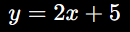

Suitable.

---

Example

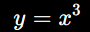

Not suitable without feature engineering.

---

## 2. Independent Observations

Each training sample should be independent of the others.

---

## 3. Low Noise

The data should not be dominated by random errors.

---

## 4. Features Should Be Scaled

This assumption is extremely important.

Example

| Feature |            Scale |
| ------- | ---------------: |
| Age     |            20–80 |
| Income  | 20,000–2,000,000 |

Without scaling:

Income dominates the penalty.

After StandardScaler:

Both contribute fairly.

Therefore Elastic Net almost always uses

```python
StandardScaler()
```

before training.

---

## 5. Moderate Multicollinearity is Acceptable

Unlike Linear Regression,

Elastic Net is specifically designed to handle correlated features.

---

# Types / Variants

Elastic Net itself does not have separate algorithmic variants like Decision Trees or SVMs, but it can behave differently depending on `l1_ratio`.

---

## Pure Ridge

```python
l1_ratio = 0
```

Behavior:

* No feature selection
* Stable coefficients

---

## Mostly Ridge

```python
l1_ratio = 0.2
```

Behavior:

* Mostly shrinking
* Very little feature removal

---

## Balanced Elastic Net

```python
l1_ratio = 0.5
```

Behavior:

* Good balance
* Common starting point

---

## Mostly Lasso

```python
l1_ratio = 0.8
```

Behavior:

* More feature selection
* More sparsity

---

## Pure Lasso

```python
l1_ratio = 1
```

Equivalent to Lasso Regression.

---

# Decision Boundary / Model Behavior

Elastic Net is a **regression algorithm**, so it does **not** have a decision boundary like classification algorithms.

Instead, it learns a **linear prediction function**.

Example:

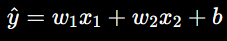

Regularization changes the **coefficients**, not the linear nature of the model.

---

## Behavior when alpha increases

As alpha increases:

* Coefficients shrink.
* Some coefficients become zero.
* Model complexity decreases.
* Variance decreases.
* Bias increases.

---

## Behavior when l1_ratio increases

As `l1_ratio` moves toward 1:

* More L1 penalty.
* More coefficients become zero.
* Stronger feature selection.

As it moves toward 0:

* More L2 penalty.
* Fewer coefficients become zero.
* More stable coefficients.

---

# Advantages & Disadvantages

## Advantages

### Combines Ridge and Lasso

Gets benefits of both methods.

---

### Performs Feature Selection

Can remove unnecessary variables.

---

### Handles Correlated Features Well

Better than Lasso in many correlated datasets.

---

### Reduces Overfitting

Regularization improves generalization.

---

### Flexible

Can imitate Ridge, Lasso, or a balance of both by adjusting `l1_ratio`.

---

## Disadvantages

### Needs Hyperparameter Tuning

Both `alpha` and `l1_ratio` must be selected carefully.

---

### Requires Feature Scaling

Performance can degrade without scaling.

---

### Still Linear

Cannot model highly nonlinear relationships on its own.

---

### Can Underfit

Very large `alpha` values can oversimplify the model.

---

# When To Use / Avoid

## Use Elastic Net When

✅ You have many features.

✅ Features are highly correlated.

✅ You want automatic feature selection.

✅ You want a model less aggressive than Lasso but more selective than Ridge.

✅ You need better generalization than ordinary Linear Regression.

---

## Avoid Elastic Net When

❌ The relationship is highly nonlinear (unless you first engineer nonlinear features, e.g., Polynomial Features).

❌ Your dataset is extremely small and simple, where plain Linear Regression may suffice.

❌ Interpretability is not important and a nonlinear model (e.g., Random Forest or Gradient Boosting) clearly performs better.

❌ Your features are not scaled and you cannot preprocess them (since the penalty depends on coefficient magnitudes).

---